
# Plot Cross-Validation Summaries for Multiple Experiments

This notebook:
- Loads multiple `summary_mean_std.json` files (each summarizing mean±std across folds for one experiment).
- Builds a tidy DataFrame across experiments.
- Plots **bar charts with error bars** (mean ± std) for each metric.
- Exports a combined CSV and a paper-ready **LaTeX table**.

> **How to use**: Edit the dictionary in **Cell 2** to point to your experiments.


In [1]:

# === Cell 1: Imports & setup ===
import os, json, re
from pathlib import Path
from typing import Dict, Any, List, Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# rendering setup
%matplotlib inline

# output directory for generated files (plots, CSV, LaTeX table)
OUT_DIR = Path('./plots_out')
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Saving outputs to:', OUT_DIR.resolve())

# Load classification results
df = pd.read_csv("./results/final_recognition_results.csv")



Saving outputs to: /sfs/gpfs/tardis/home/cjh9fw/Desktop/2025/DataCollectionSystem/benchmarks/gesture_recognition/MTRSAP/plots_out


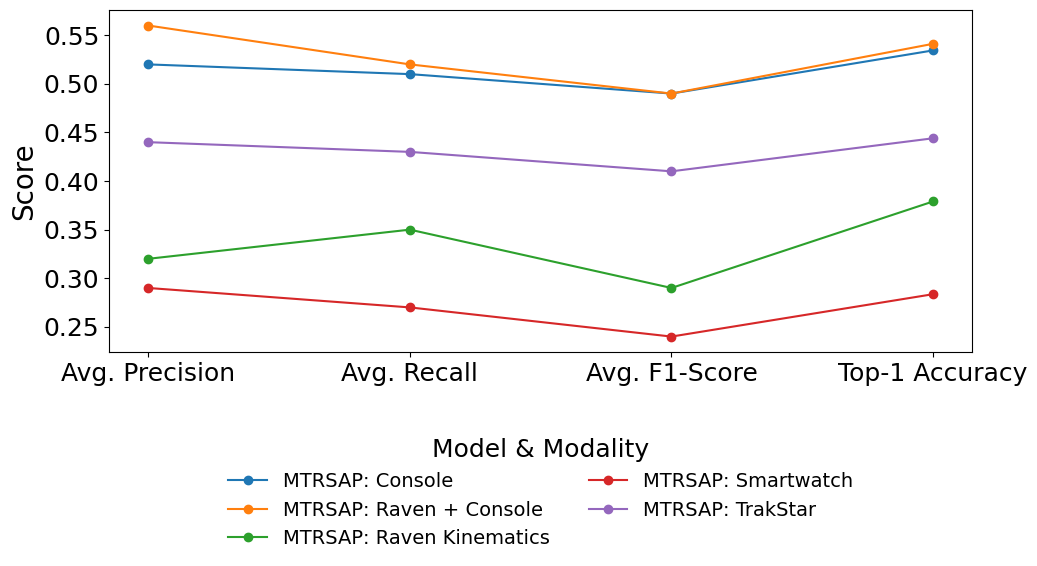

In [2]:

# Font and figure size variables
axis_label_fontsize = 20
tick_fontsize = 18
legend_fontsize = 14
legend_title_fontsize = 18
fig_width, fig_height = 6,6




sns.reset_orig()

# Normalize accuracy if it's in percentage
if df["accuracy"].max() > 1.0:
    df["accuracy"] /= 100.0

# Create combined legend label
df["model_modality"] = df["model"] + ": " + df["modality"]

# Melt metrics
df_melted = df.melt(
    id_vars=["model", "modality", "model_modality"],
    value_vars=["average_precision", "average_recall", "average_f1", "accuracy"],
    var_name="Metric",
    value_name="Score"
)

# Sort metric order
metric_order = ["average_precision", "average_recall", "average_f1", "accuracy"]
metric_title_map = {
    "average_precision": "Avg. Precision",
    "average_recall": "Avg. Recall",
    "average_f1": "Avg. F1-Score",
    "accuracy": "Top-1 Accuracy",
}

# Plot setup
plt.figure(figsize=(fig_width, fig_height))

# Plot each model_modality as a separate line
for name, group in df_melted.groupby("model_modality"):
    model = group["model"].iloc[0]
    modality = group["modality"].iloc[0]
    
    # Style logic
    ls = '-' if model == 'MTRSAP' else '--'
    marker = 'o' if model == 'MTRSAP' else 'X'
    color = None
    
    plt.plot(
        [metric_title_map[m] for m in group["Metric"]],
        group["Score"],
        label=name,
        linestyle=ls,
        marker=marker,
        color=color
    )

# Final touches
plt.ylabel("Score", fontsize=axis_label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)

# Legend
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=2,
    frameon=False,
    fontsize=legend_fontsize,
    title='Model & Modality',
    title_fontsize=legend_title_fontsize
)

plt.tight_layout(rect=[0, 0, 1.8, 1])
plt.savefig(f'{OUT_DIR}/classification_results.png', dpi=300, bbox_inches='tight')
plt.show()
